# Superstore Sales Analytics and Profit Prediction

A practical analysis of the Superstore dataset covering data quality checks, sales and profit patterns, customer segmentation, order-line profit prediction, and a lightweight monthly sales forecast.

## Overview and Goals

This notebook analyzes the **Superstore sales dataset (2014–2017)** to support practical retail decisions.

The workflow answers five business questions:

- Which months, regions, categories, and sub-categories drive sales and profit?
- Where do discounts, geography, or product mix create margin pressure?
- Which customers are most valuable or at risk based on RFM segmentation?
- Can we build a reusable baseline model to estimate order-line profit from known order details?
- What does a simple monthly sales forecast suggest for near-term planning?

## Important Scope Note

The main supervised model in this notebook is **profit prediction**, not pure future sales forecasting.

The model predicts **line-item profit after core transaction details are known**. The final forecasting section is included as a lightweight, exploratory sales trend estimate, not as a production-grade forecasting system.

## Config and Imports

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance


RANDOM_SEED = 42
PRIMARY_COLOR = "#4C78A8"
CV_MAX_ROWS = 3000
ARTIFACTS_DIR = Path("artifacts")

DATA_PATH_CANDIDATES = [
    Path("/kaggle/input/superstore-dataset-final/Sample - Superstore.csv"),
    Path("data/raw/Sample - Superstore.csv"),
    Path("../data/raw/Sample - Superstore.csv"),
]


def resolve_data_path(candidate_paths):
    """Resolve the Superstore CSV path for Kaggle or a local GitHub-style layout."""
    for path in candidate_paths:
        if path.exists():
            return path

    expected_paths = "\n".join(f"- {path}" for path in candidate_paths)
    raise FileNotFoundError(
        "Dataset file not found. Expected one of:\n"
        f"{expected_paths}\n\n"
        "For Kaggle, attach the dataset named 'superstore-dataset-final'.\n"
        "For local/GitHub use, place the CSV at 'data/raw/Sample - Superstore.csv'."
    )


warnings.filterwarnings("ignore", category=FutureWarning)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)


def rmse_score(y_true, y_pred):
    """Return root mean squared error with broad scikit-learn compatibility."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


Matplotlib is building the font cache; this may take a moment.


## Data Loading

In [2]:
DATA_PATH = resolve_data_path(DATA_PATH_CANDIDATES)

df = pd.read_csv(DATA_PATH, encoding="windows-1252")
print(f"Loaded data from: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

Loaded data from: data/raw/Sample - Superstore.csv
Shape: 9,994 rows × 21 columns


## Initial Data Exploration

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.000,41.914
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.000,219.582
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.000,6.871
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.577,5,0.450,-383.031
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.200,2.516


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,"9,994.000","9,994.000","9,994.000","9,994.000","9,994.000","9,994.000"
mean,"4,997.500","55,190.379",229.858,3.790,0.156,28.657
std,"2,885.164","32,063.693",623.245,2.225,0.206,234.260
min,1.000,"1,040.000",0.444,1.000,0.000,"-6,599.978"
25%,"2,499.250","23,223.000",17.280,2.000,0.000,1.729
50%,"4,997.500","56,430.500",54.490,3.000,0.200,8.666
75%,"7,495.750","90,008.000",209.940,5.000,0.200,29.364
max,"9,994.000","99,301.000","22,638.480",14.000,0.800,"8,399.976"


In [6]:
df.shape

(9994, 21)

## Data Cleaning

### Check missing values & duplicates


In [7]:
# Missing values 
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### We quantify missing values per column to plan imputation or safe drops.

In [8]:
# Remove duplicates
df.duplicated().sum()

np.int64(0)

### We remove duplicates to prevent double counting.

### Convert to datetime

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.drop_duplicates(inplace=True)

### We convert Order Date and Ship Date to datetime, unlocking time‑based analysis and lead‑time metrics.

In [10]:
sales_month_by_period  = (df.set_index('Order Date').resample('M')['Sales'].sum().sort_index())
profit_month_by_period = (df.set_index('Order Date').resample('M')['Profit'].sum().sort_index())


We resample by calendar month to build two core time series:

- `sales_month_by_period`: total sales per month
- `profit_month_by_period`: total profit per month

These series support trend charts, seasonality checks, and the exploratory forecast at the end.

In [11]:
kpis = {}
kpis['total_sales']   = float(df['Sales'].sum())
kpis['total_profit']  = float(df['Profit'].sum())
kpis['avg_ship_days'] = (df['Ship Date'] - df['Order Date']).dt.days.clip(lower=0).mean()

kpis['top_months_sales'] = (sales_month_by_period.sort_values(ascending=False)
                                            .head(5).index.strftime('%Y-%m').tolist())
kpis['highest_region'] = df.groupby('Region')['Sales'].sum().idxmax()
kpis['top_category']   = df.groupby('Category')['Sales'].sum().idxmax()

today = df['Order Date'].max() + pd.Timedelta(days=1)
_rfm = df.groupby('Customer ID').agg(
    Recency  = ('Order Date', lambda x: (today - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary =('Sales', 'sum')
).reset_index()

_rfm['R_Score'] = pd.qcut(_rfm['Recency'], 4, labels=[4,3,2,1])
_rfm['F_Score'] = pd.qcut(_rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
_rfm['M_Score'] = pd.qcut(_rfm['Monetary'], 4, labels=[1,2,3,4])
_rfm[['R_Score','F_Score','M_Score']] = _rfm[['R_Score','F_Score','M_Score']].astype(int)
_rfm['RFM_Sum'] = _rfm[['R_Score','F_Score','M_Score']].sum(axis=1)

def _seg(s):
    if s >= 10: return 'Champions'
    if s >= 8:  return 'Loyal'
    if s >= 6:  return 'Potential'
    return 'At Risk'
_rfm['Segment'] = _rfm['RFM_Sum'].apply(_seg)

rfm_pct = (_rfm['Segment'].value_counts(normalize=True)*100).round(0).astype(int)
for g in ['Champions','Loyal','Potential','At Risk']:
    if g not in rfm_pct: rfm_pct.loc[g] = 0
rfm_pct = rfm_pct[['Champions','Loyal','Potential','At Risk']]

exec_md = f"""
## Executive Summary

- Strong seasonality with **December spikes**; **Top months:** {", ".join(kpis['top_months_sales'])}.
- **{kpis['highest_region']}** leads by sales; **{kpis['top_category']}** is the top category.
- **Avg. shipping time ≈ {kpis['avg_ship_days']:.2f} days**.
- **Total sales:** {kpis['total_sales']:,.2f} · **Total profit:** {kpis['total_profit']:,.2f}.
- **RFM mix:** Champions {rfm_pct['Champions']}% · Loyal {rfm_pct['Loyal']}% · Potential {rfm_pct['Potential']}% · At Risk {rfm_pct['At Risk']}%.
"""
display(Markdown(exec_md))


## Executive Summary

- Strong seasonality with **December spikes**; **Top months:** 2017-11, 2016-12, 2017-09, 2017-12, 2014-09.
- **West** leads by sales; **Technology** is the top category.
- **Avg. shipping time ≈ 3.96 days**.
- **Total sales:** 2,297,200.86 · **Total profit:** 286,397.02.
- **RFM mix:** Champions 24% · Loyal 28% · Potential 23% · At Risk 25%.


### Categorical Coverage

## Exploratory Data Analysis (EDA)

### Correlation Matrix

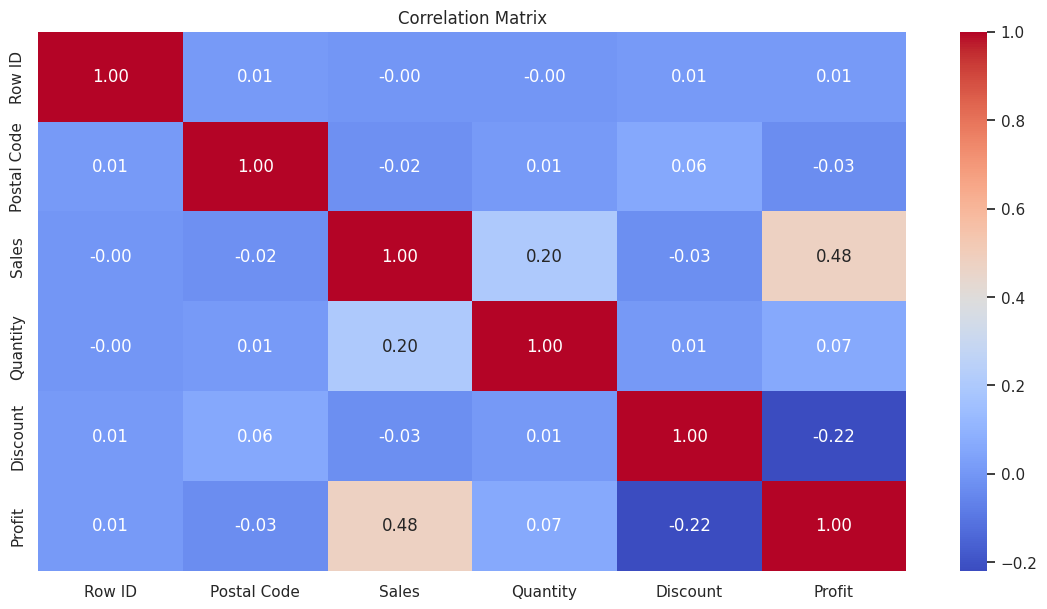

In [12]:
plt.figure(figsize=(14, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Correlation heatmap to check relationships.

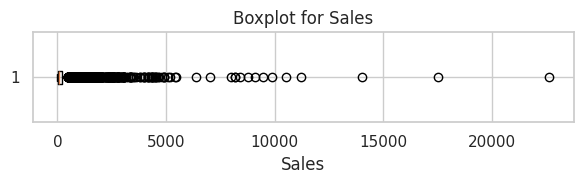

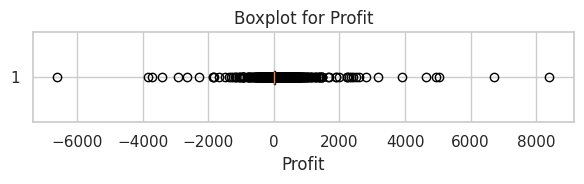

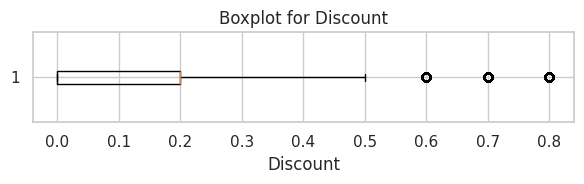

In [13]:
for col in ['Sales', 'Profit', 'Discount']:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot for {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Boxplot to detect profit outliers.

### Monthly Sales Trend

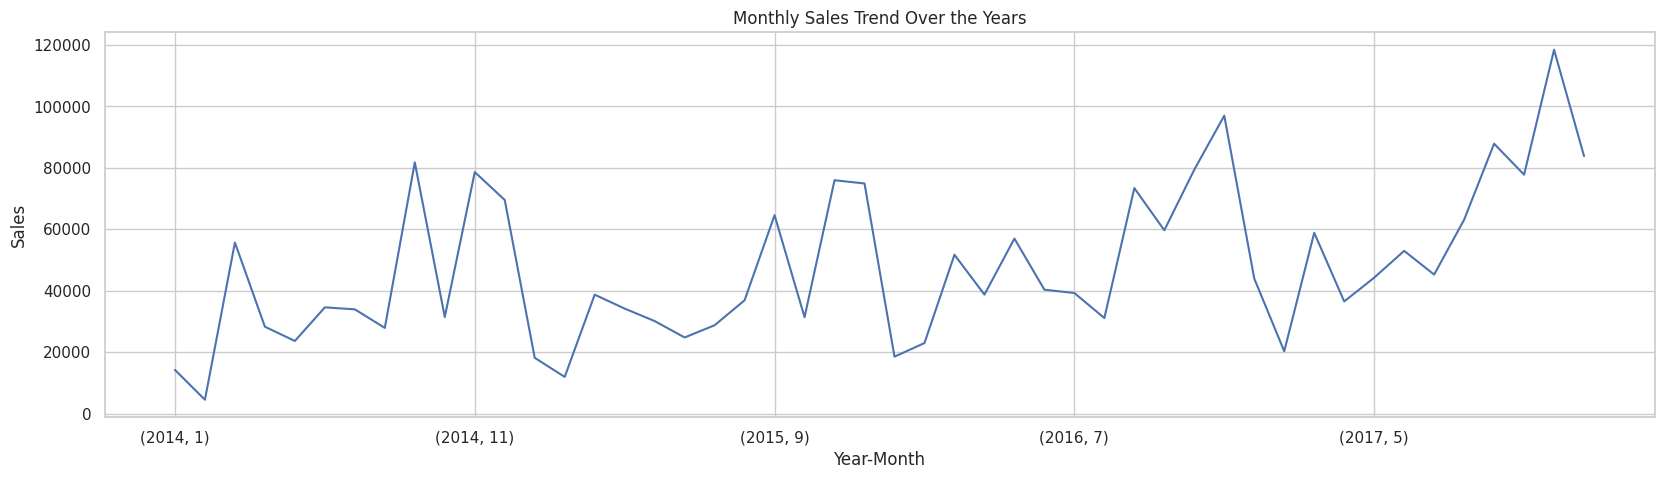

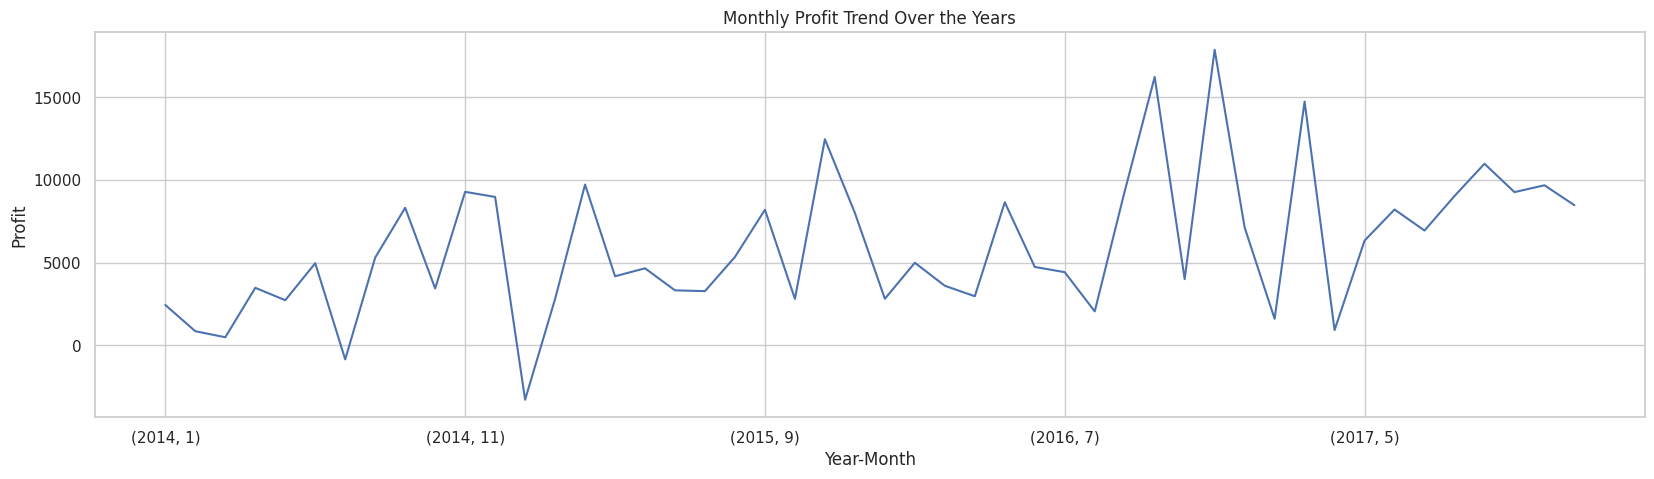

In [14]:
sales_year_month = (df
    .groupby([df['Order Date'].dt.year.rename('Year'),
              df['Order Date'].dt.month.rename('Month')])['Sales']
    .sum()
    .sort_index())

plt.figure(figsize=(20,5))
sales_year_month.plot()
plt.title('Monthly Sales Trend Over the Years')
plt.xlabel('Year-Month'); plt.ylabel('Sales'); plt.show()

profit_year_month = (df
    .groupby([df['Order Date'].dt.year.rename('Year'),
              df['Order Date'].dt.month.rename('Month')])['Profit']
    .sum()
    .sort_index())

plt.figure(figsize=(20,5))
profit_year_month.plot()
plt.title('Monthly Profit Trend Over the Years')
plt.xlabel('Year-Month'); plt.ylabel('Profit'); plt.show()


### Monthly sales trend across years.

### Heatmap - Monthly Sales per Year

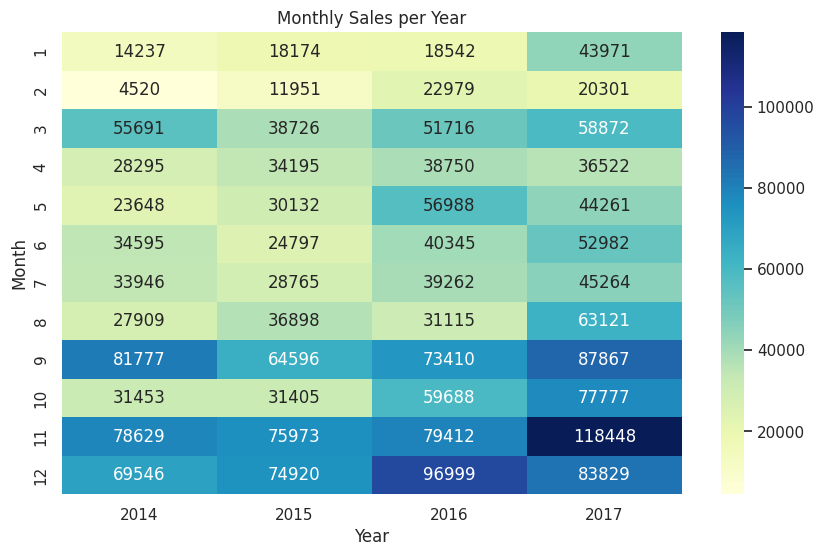

In [15]:
pivot = df.pivot_table(index=df['Order Date'].dt.month, columns=df['Order Date'].dt.year, values='Sales', aggfunc='sum')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Monthly Sales per Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

### Compare December across years to check whether holiday uplift is getting stronger or weaker.

### Line Plot

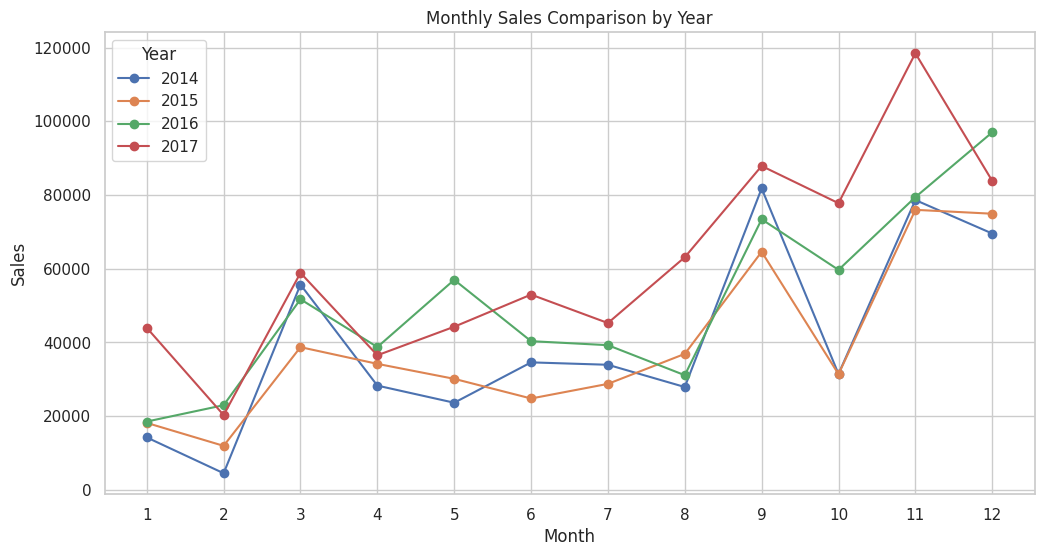

In [16]:
plt.figure(figsize=(12,6))
for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker='o', label=str(year))

plt.title('Monthly Sales Comparison by Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(title='Year')
plt.xticks(pivot.index)
plt.show()      


### compares intra‑year curves month‑by‑month.

### Bar Plot 

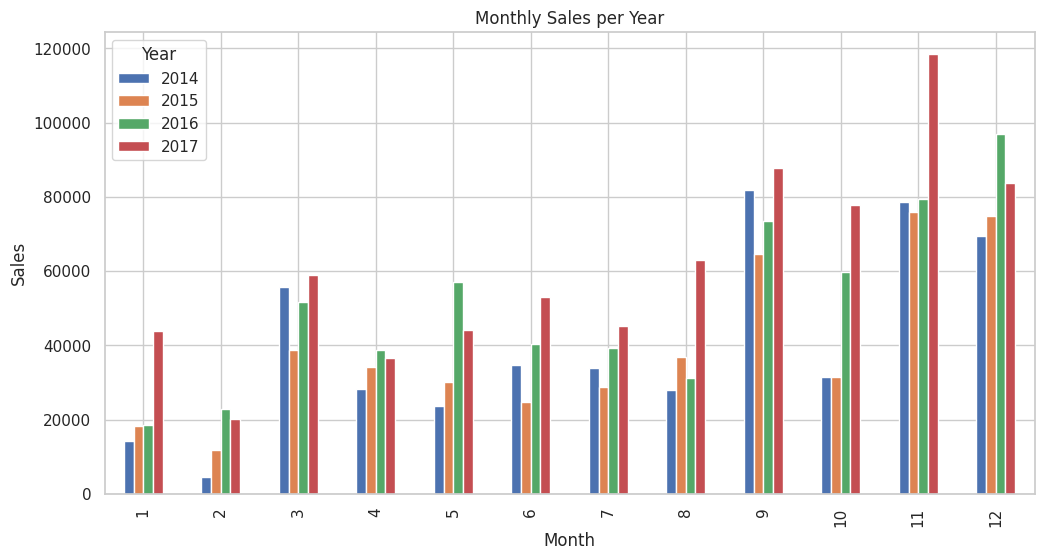

In [17]:
pivot.plot(kind='bar', figsize=(12,6))
plt.title('Monthly Sales per Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(title='Year')
plt.show()

### stacks months side‑by‑side across years.

### Sales vs Profit

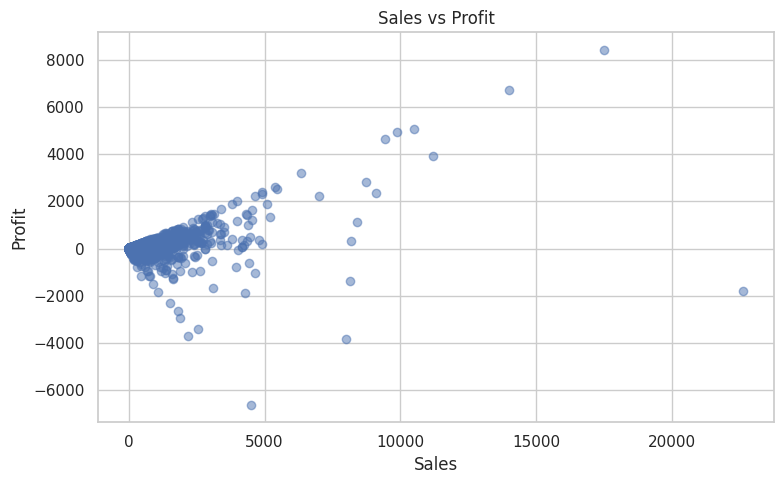

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### Each point is a line item; the slope/horizontal spread hints whether higher sales typically mean higher profit or if discounting freights margins.

### Analysis Sales by Region

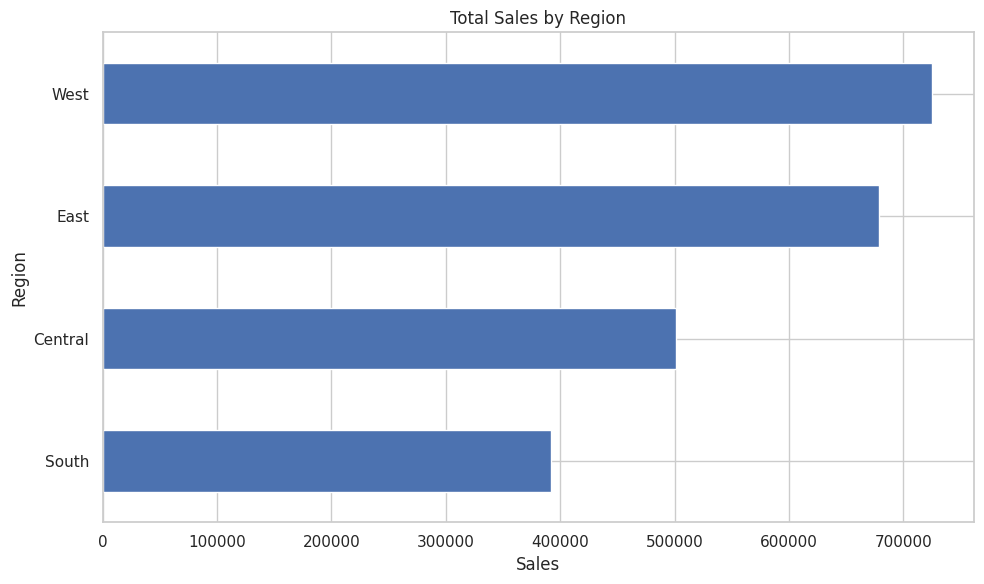

In [19]:
top_regions = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
top_regions.sort_values().plot(kind='barh')
plt.title('Total Sales by Region')
plt.xlabel('Sales')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### Regional totals identify footprint strength.

### Analysis Sales by States

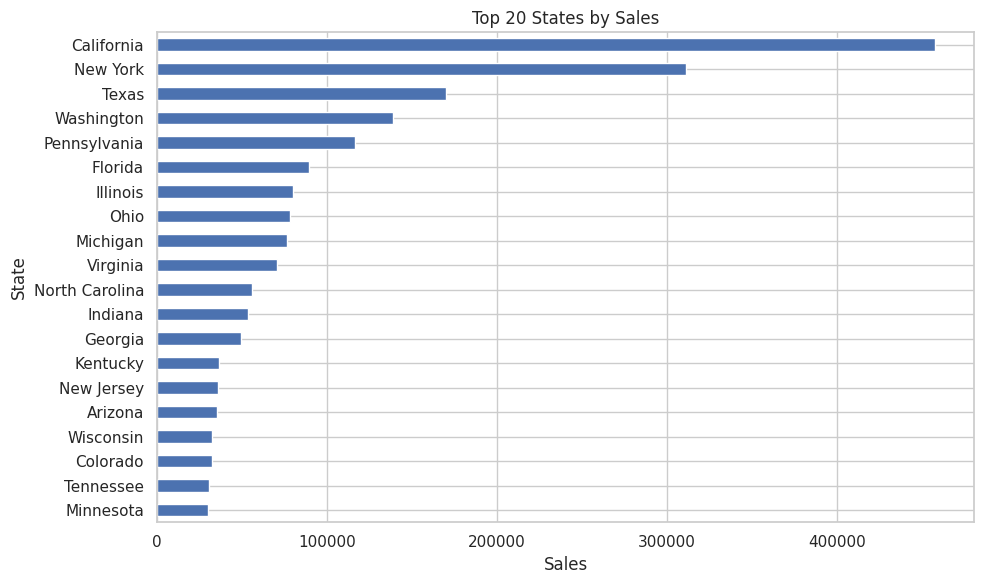

In [20]:
top_States_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_States_sales.sort_values().plot(kind='barh')
plt.title('Top 20 States by Sales')
plt.xlabel('Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### A ranked view of where revenue concentrates.

### Analysis Sales by Cities 

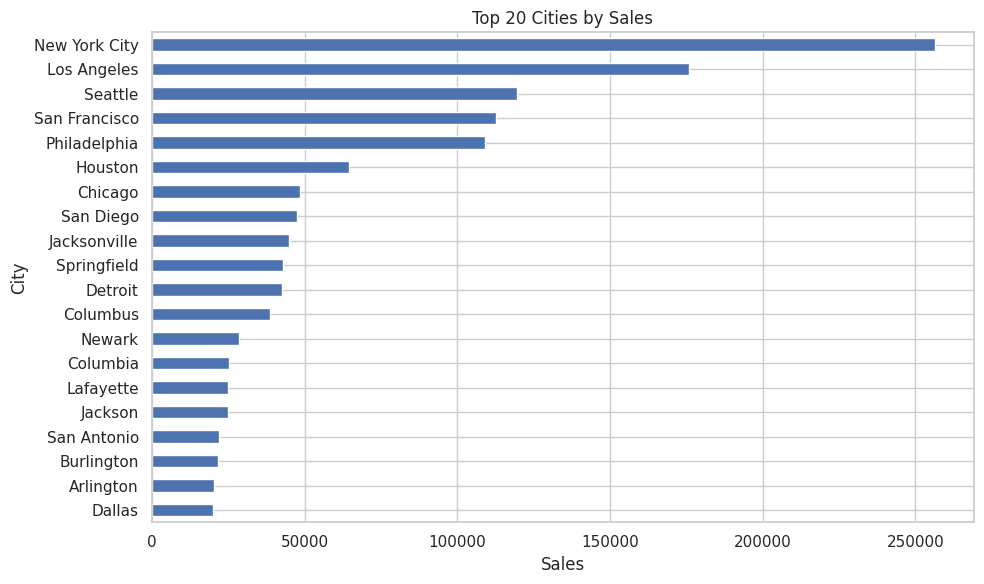

In [21]:
top_Cities_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_Cities_sales.sort_values().plot(kind='barh')
plt.title('Top 20 Cities by Sales')
plt.xlabel('Sales')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Great inputs for geo‑targeted ads and local partnerships.

### Analysis Profit by States 

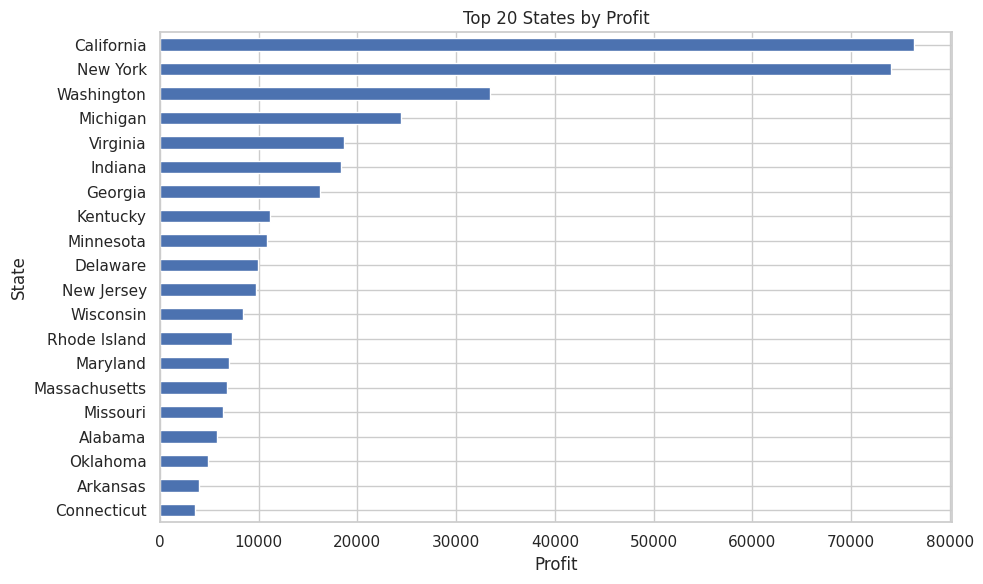

In [22]:
top_States_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_States_profit.sort_values().plot(kind='barh')
plt.title('Top 20 States by Profit')
plt.xlabel('Profit')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### If a high‑sales state is low‑profit, investigate discount policy, returns, and last‑mile costs.

### Analysis Profit by Cities 

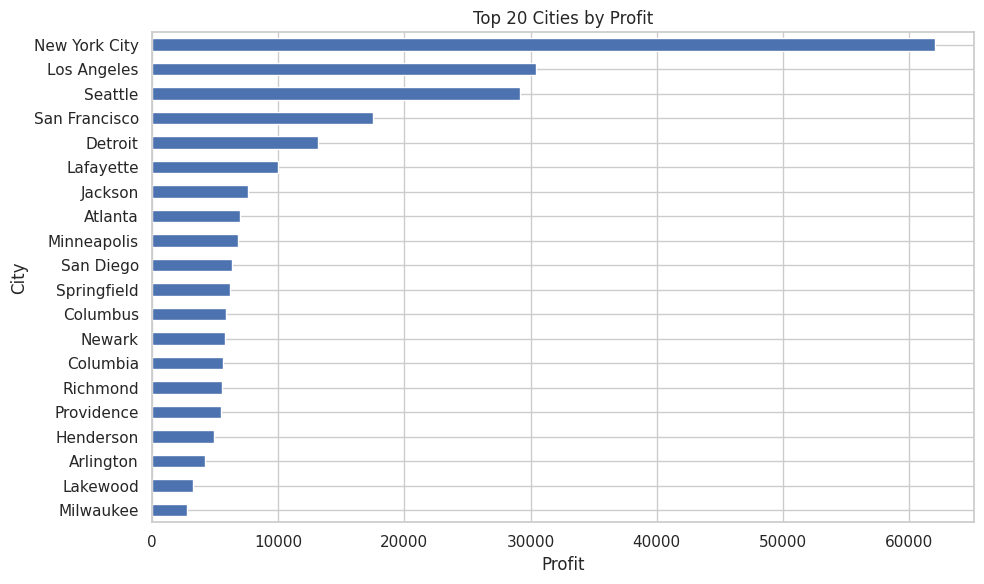

In [23]:
top_Cities_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_Cities_profit.sort_values().plot(kind='barh')
plt.title('Top 20 Cities by Profit')
plt.xlabel('Profit')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Use this to allocate account managers and service levels where margin justifies investment.

### Category & Sub-Category Sales Analysis

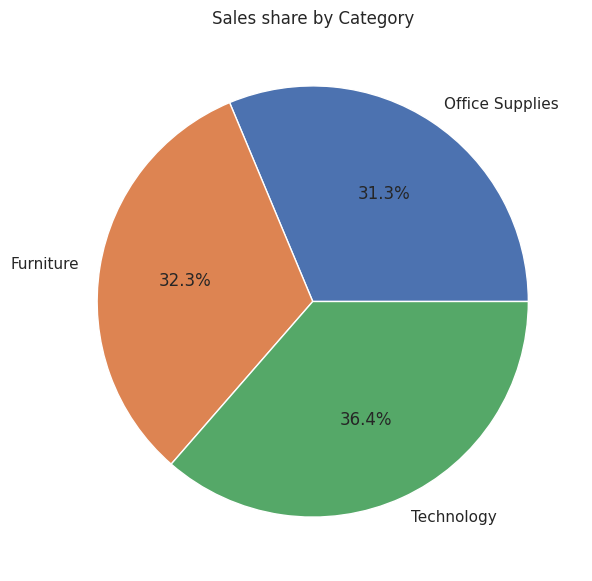

In [24]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(10,7))
cat_sales.plot(kind='pie', autopct='%1.1f%%', title='Sales share by Category')
plt.ylabel('')
plt.show()

### High‑level composition of revenue by Furniture / Office Supplies / Technology.


### Top Products Word Cloud

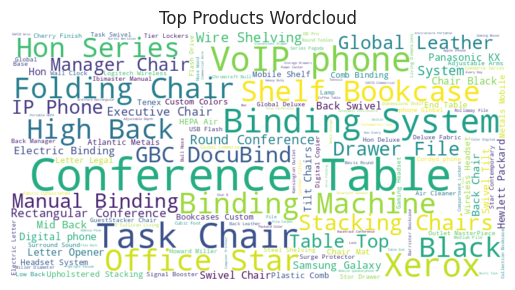

In [25]:
try:
    from wordcloud import WordCloud
    _txt = " ".join(df.loc[df['Sales'] > df['Sales'].quantile(0.75), 'Product Name'].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(_txt)
    plt.imshow(wordcloud, interpolation='bilinear'); plt.axis('off'); plt.title("Top Products Wordcloud")
    plt.show()
except Exception as e:
    print("WordCloud skipped →", e)

### A quick, qualitative sense of products dominating top‑quartile sales.


### Analysis Profit by Category

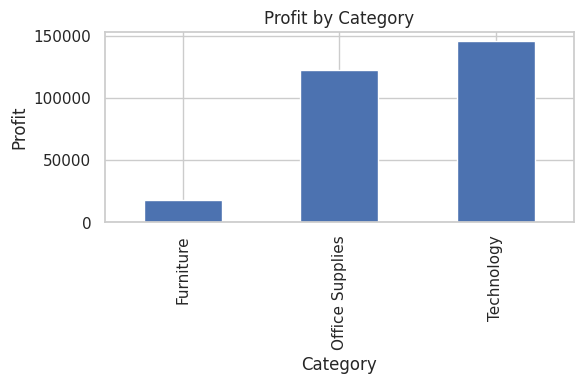

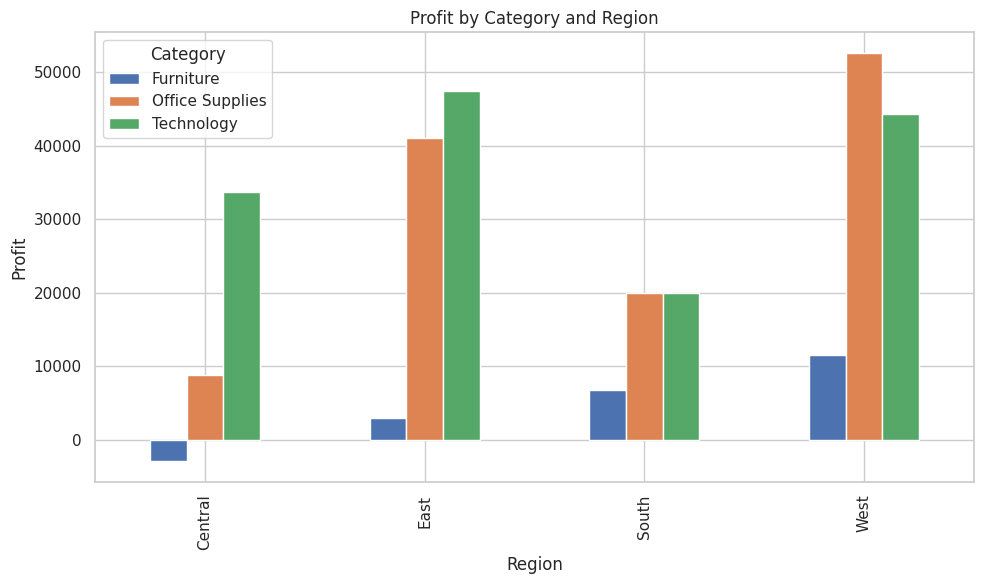

In [26]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values()
plt.figure(figsize=(6,4))
profit_by_category.plot(kind='bar', title='Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

profit_region_category = df.pivot_table(
    index='Region',
    columns='Category',
    values='Profit',
    aggfunc='sum',
)
profit_region_category.plot(kind='bar', figsize=(10, 6))
plt.title('Profit by Category and Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### Category bars show margin strength by line.

### Analysis Discount impact on Profit

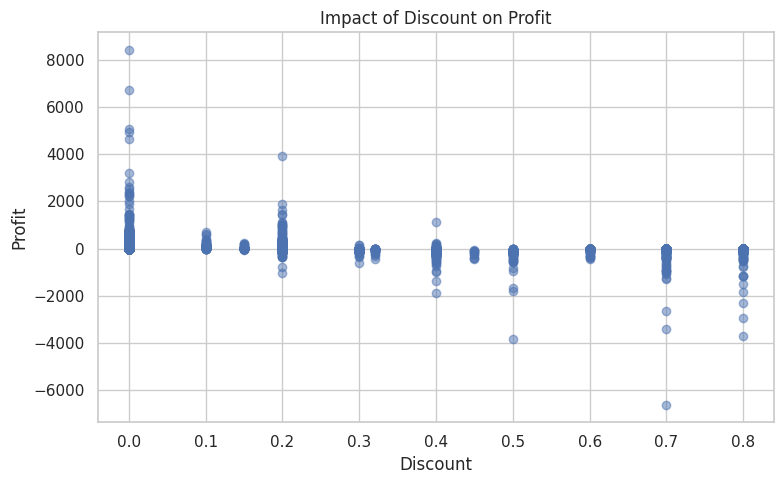

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### This visual shows whether higher discounts correlate with lower profit.


### Loss-Making Sub-Categories Analysis

In [28]:
loss_products = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)
print('Most Loss-Making Sub-Categories:')
loss_products

Most Loss-Making Sub-Categories:


Sub-Category
Tables        -17,725.481
Bookcases      -3,472.556
Supplies       -1,189.100
Fasteners         949.518
Machines        3,384.757
Labels          5,546.254
Art             6,527.787
Envelopes       6,964.177
Furnishings    13,059.144
Appliances     18,138.005
Name: Profit, dtype: float64

### We rank sub‑categories with lowest total profit.


### Profit Distribution

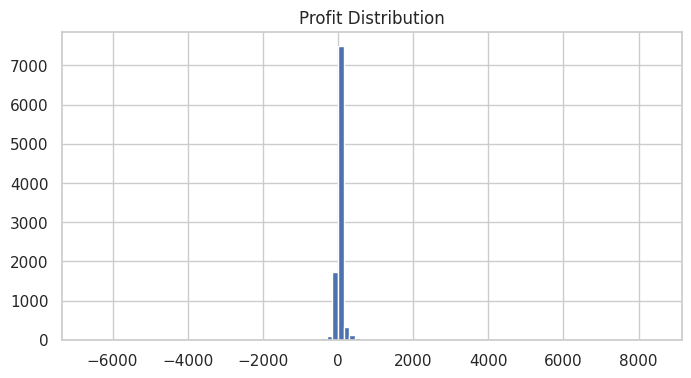

Profit Range: -6599.978 → 8399.976


In [29]:
plt.figure(figsize=(8,4))
plt.hist(df['Profit'], bins=100)
plt.title('Profit Distribution')
plt.show()
print("Profit Range:", df['Profit'].min(), "→", df['Profit'].max())


### We check the symmetry and tails of profit at the line level.


### Analysis Top Customers Sales

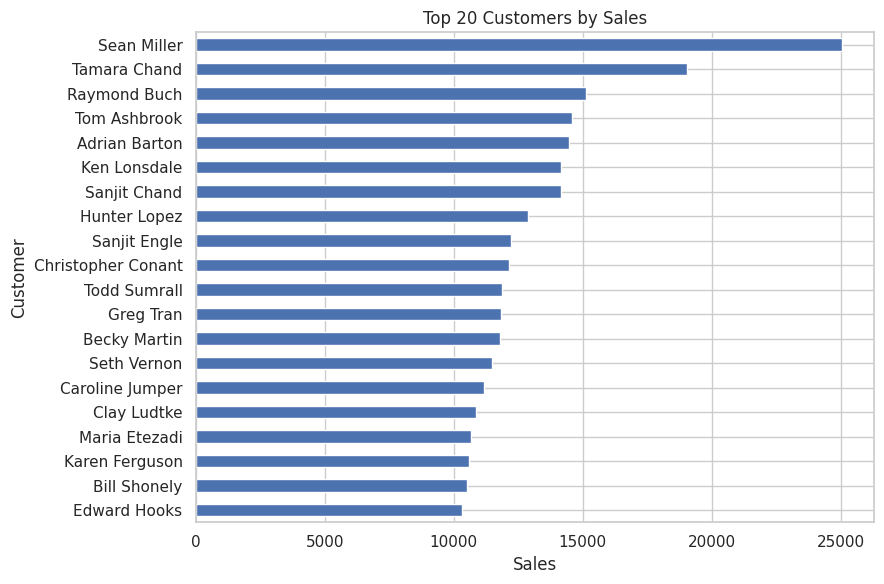

In [30]:
top_customers_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 6))
top_customers_sales.sort_values().plot(kind='barh')
plt.title('Top 20 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

### Identifies our whales—key for VIP programs, priority support, and contract renewals.

### Analysis Top Customers Profit

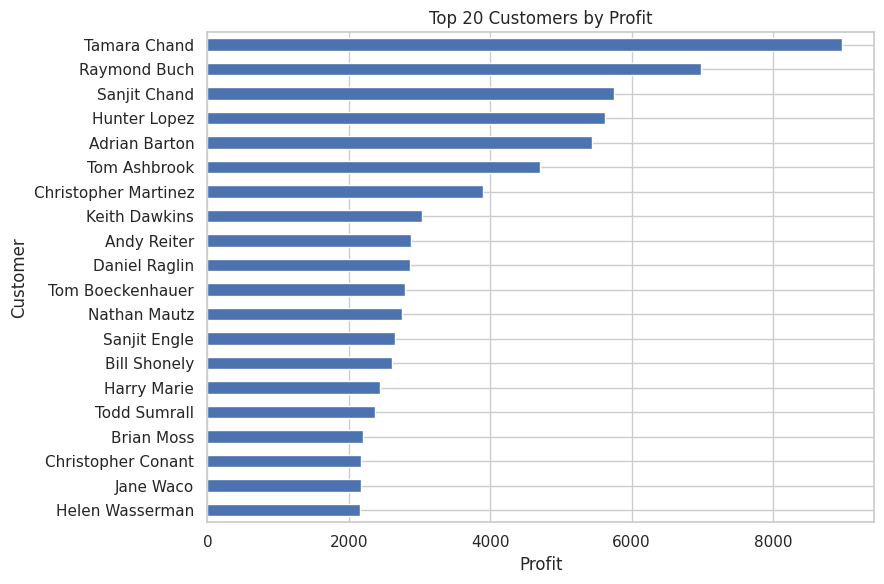

In [31]:
top_customers_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 6))
top_customers_profit.sort_values().plot(kind='barh')
plt.title('Top 20 Customers by Profit')
plt.xlabel('Profit')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

### Revenue is vanity, profit is sanity.


### Total Profit Margin by Category

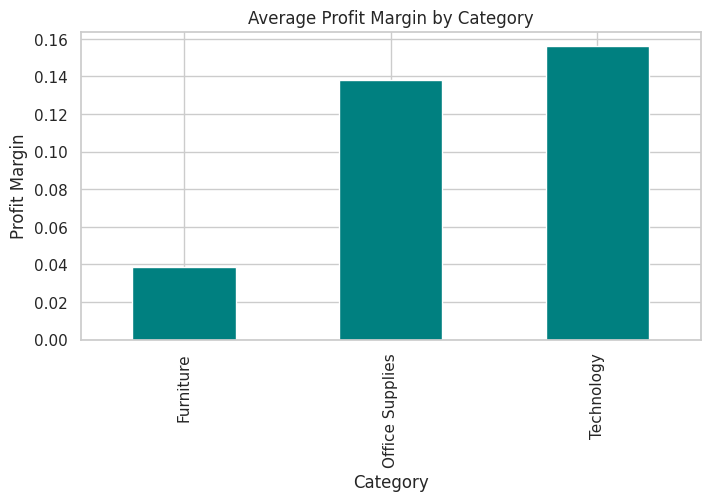

In [32]:
avg_margin_by_cat = (df['Profit'] / df['Sales']).replace([np.inf, -np.inf], np.nan)
margin_by_category = df.assign(_pm=avg_margin_by_cat).groupby('Category')['_pm'].mean().sort_values()
plt.figure(figsize=(8,4))
margin_by_category.plot(kind='bar', color='teal')
plt.title('Average Profit Margin by Category')
plt.ylabel('Profit Margin')
plt.show()


### We compute line‑level margin and average by category.


### Total Sales by Sub-Category

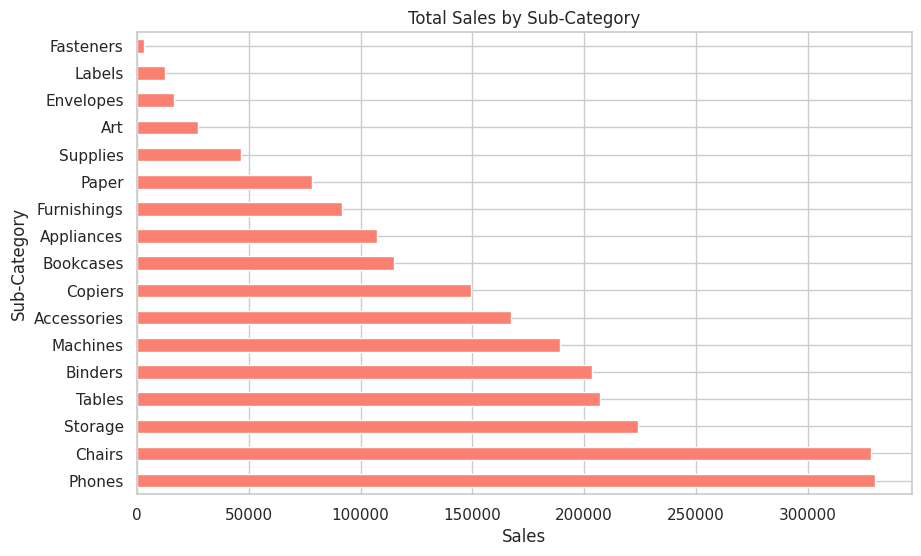

In [33]:
subcat_by_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
subcat_by_sales.plot(kind='barh', color='salmon')
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.show()


### Great for merchandising decisions and shelf space allocation.

### Total Profit by Sub-Category

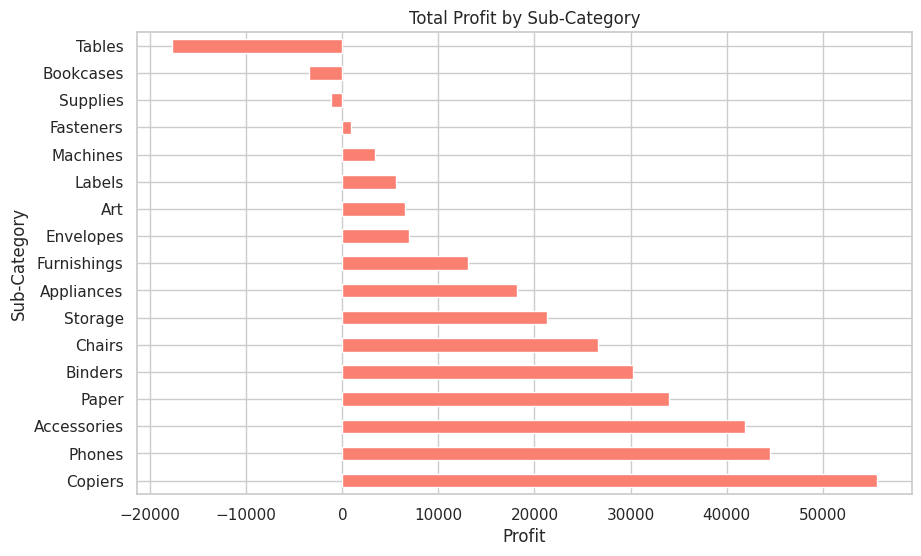

In [34]:
subcat_by_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
subcat_by_profit.plot(kind='barh', color='salmon')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.show()


### Great for merchandising decisions and shelf space allocation.

### Shipping Time Distribution

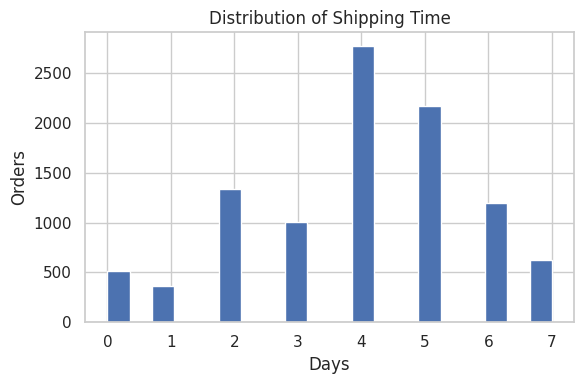

In [35]:
shipping_time = (df['Ship Date'] - df['Order Date']).dt.days.clip(lower=0)
plt.figure(figsize=(6,4))
plt.hist(shipping_time, bins=20)
plt.title('Distribution of Shipping Time')
plt.xlabel('Days')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

### Shorter, more predictable shipping improves conversion and reduces returns.


### Yearly Sales/Profit


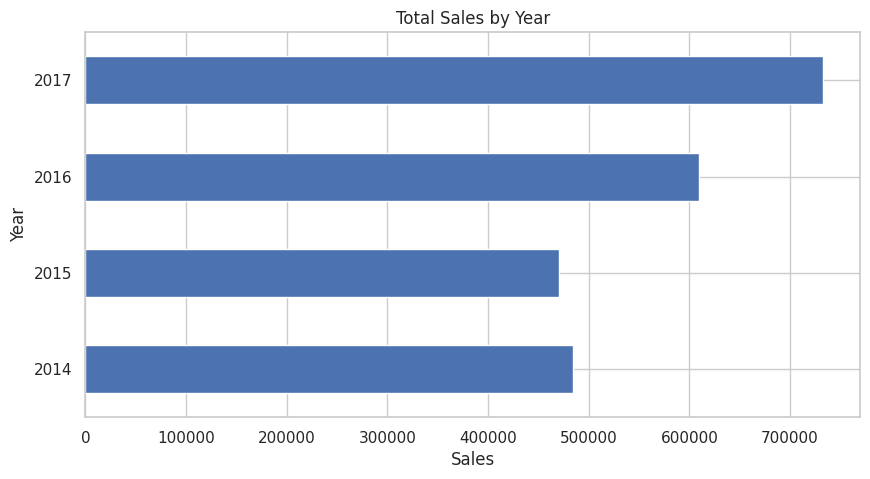

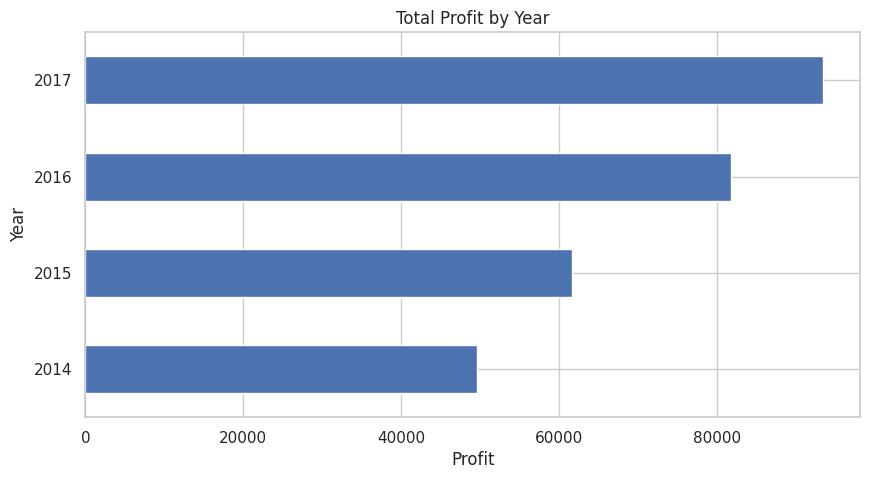

In [36]:
df_year = df.assign(OrderY=df['Order Date'].dt.year)
plt.figure(figsize=(10,5)); df_year.groupby('OrderY')['Sales'].sum().plot.barh()
plt.title('Total Sales by Year'); plt.xlabel('Sales'); plt.ylabel('Year'); plt.show()
plt.figure(figsize=(10,5)); df_year.groupby('OrderY')['Profit'].sum().plot.barh()
plt.title('Total Profit by Year'); plt.xlabel('Profit'); plt.ylabel('Year'); plt.show()

### Use alongside seasonality plots for a full temporal story.

### Key Business Metrics (KPIs)

In [37]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
total_orders = df['Order ID'].nunique()
unique_customers = df['Customer ID'].nunique()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Average Order Value: {avg_order_value:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Unique Customers: {unique_customers}")


Total Sales: 2,297,200.86
Total Profit: 286,397.02
Average Order Value: 458.61
Total Orders: 5009
Unique Customers: 793


### We compute:

### Total Sales / Profit

### Average Order Value (AOV)

### Orders & Unique Customers

### This anchors the analysis in a few board‑level metrics.

### Trend Smoothing - Moving Average

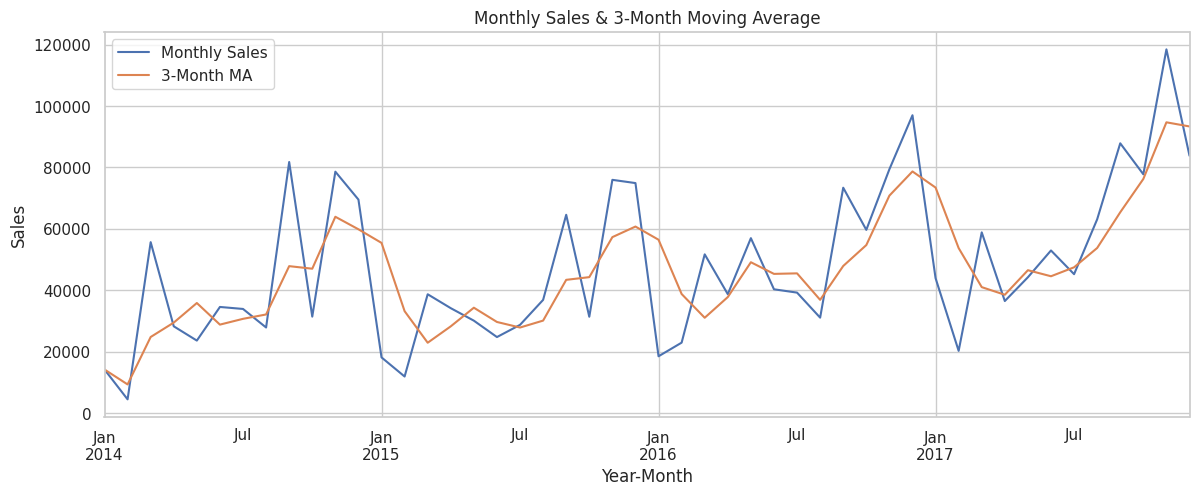

In [38]:
sales_month_smooth = sales_month_by_period.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(14,5))
sales_month_by_period.plot(label='Monthly Sales')
sales_month_smooth.plot(label='3-Month MA')  
plt.title('Monthly Sales & 3-Month Moving Average')
plt.xlabel('Year-Month'); plt.ylabel('Sales'); plt.legend(); plt.show()


### We overlay a 3‑month moving average onto monthly sales.


### Seasonal Decomposition of Sales (Time Series Analysis)

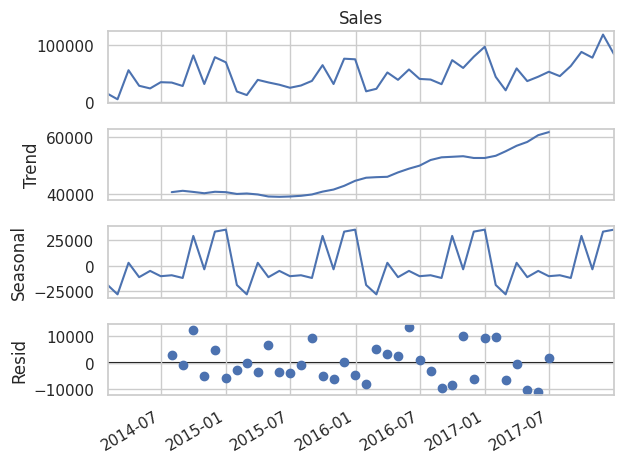

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose
sales_m = sales_month_by_period.asfreq('M').fillna(0)
res = seasonal_decompose(sales_m, model='additive', period=12)
res.plot(); plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

### Perfect for justifying inventory staging and campaign calendars.

### Cohort Analysis – Customer Retention Over Time

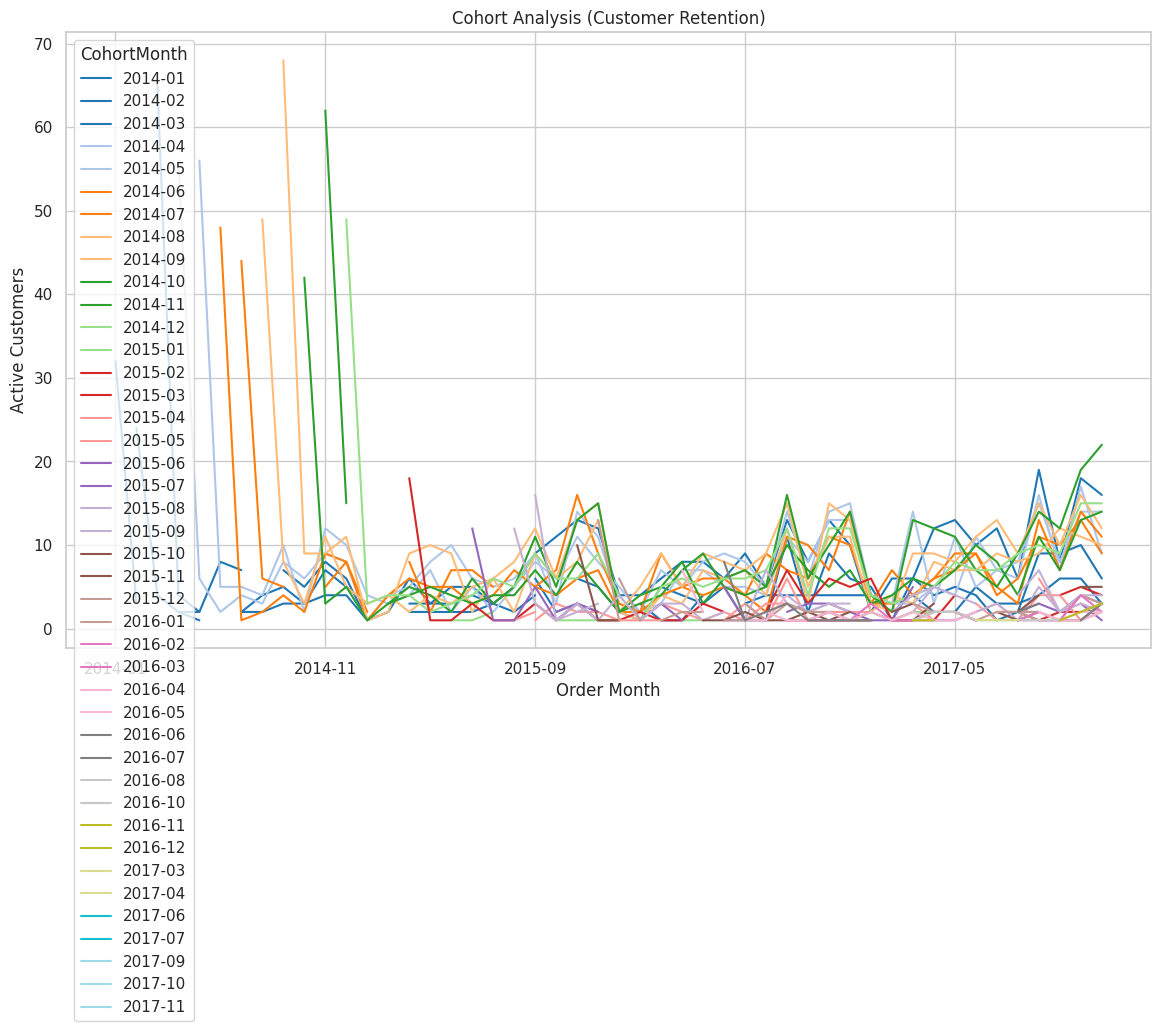

In [40]:
df_cohort = df.copy()
df_cohort['YearMonth'] = df_cohort['Order Date'].dt.to_period('M').astype(str)
df_cohort['CohortMonth'] = df_cohort.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('M').astype(str)
cohort_data = df_cohort.groupby(['CohortMonth','YearMonth'])['Customer ID'].nunique().unstack(0)
cohort_data.plot(figsize=(14,8), cmap='tab20', title='Cohort Analysis (Customer Retention)')
plt.xlabel('Order Month'); plt.ylabel('Active Customers'); plt.show()


### Cohort analysis shows strong first-month retention but a drop-off after 3–4 months, indicating need for re-engagement campaigns.

### RFM Analysis

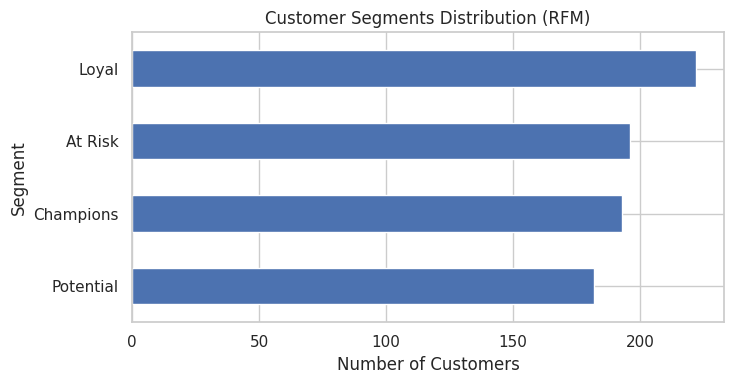

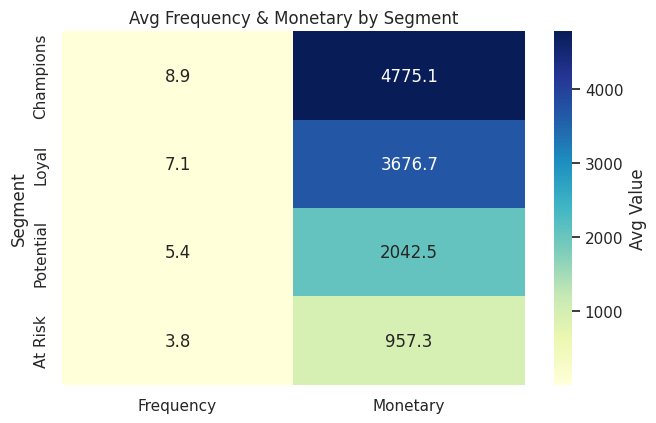

,Recency,Frequency,Monetary
Segment,,,
Champions,36.800000,8.900000,4775.100000
Loyal,92.600000,7.100000,3676.700000
Potential,150.100000,5.400000,2042.500000
At Risk,317.500000,3.800000,957.300000


In [41]:
today = df['Order Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (today - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum'),
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])
rfm[['R_Score', 'F_Score', 'M_Score']] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int)
rfm['RFM_Sum'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

def segment_map(score):
    if score >= 10:
        return 'Champions'
    if score >= 8:
        return 'Loyal'
    if score >= 6:
        return 'Potential'
    return 'At Risk'

rfm['Segment'] = rfm['RFM_Sum'].apply(segment_map)

plt.figure(figsize=(7.5, 4))
rfm['Segment'].value_counts().sort_values().plot(kind='barh')
plt.title('Customer Segments Distribution (RFM)')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

seg_kpis = (
    rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(1)
    .sort_values('Monetary', ascending=False)
)

plt.figure(figsize=(6.8, 4.4))
sns.heatmap(
    seg_kpis[['Frequency', 'Monetary']],
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Avg Value'},
)
plt.title('Avg Frequency & Monetary by Segment')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

try:
    display(seg_kpis.style.background_gradient(cmap='YlGnBu'))
except Exception:
    display(seg_kpis)

## Predictive Modeling — Order-Line Profit

This section builds a baseline model to estimate **profit per order line** from known transaction attributes.

The model is intended for margin analytics and monitoring, not for pure future sales forecasting.

## Modeling Scope and Assumptions

The target is:

```text
Profit
```

The features represent information that can be known once the order line is created or priced, such as:

- product category and sub-category
- customer segment and region
- sales amount, quantity, and discount
- order month and year

To reduce leakage and identifier noise, the model excludes:

- direct identifiers such as `Row ID`, `Order ID`, `Customer ID`, and product/customer names
- target-derived fields such as `Profit Margin`
- shipping outcome fields such as `Shipping Time`
- raw datetime fields after extracting useful calendar features

For a production deployment, the exact feature set should match the moment when the prediction is made.

## Feature Engineering

In [42]:
df_model = df.copy().sort_values("Order Date").reset_index(drop=True)

df_model["OrderY"] = df_model["Order Date"].dt.year
df_model["OrderM"] = df_model["Order Date"].dt.month
df_model["Discounted Sales"] = df_model["Sales"] * (1 - df_model["Discount"])
df_model["Sales per Quantity"] = (df_model["Sales"] / df_model["Quantity"]).replace([np.inf, -np.inf], np.nan)

# Target-derived and operational fields are created for analysis, then excluded from model features.
df_model["Profit Margin"] = (df_model["Profit"] / df_model["Sales"]).replace([np.inf, -np.inf], np.nan)
df_model["Shipping Time"] = (df_model["Ship Date"] - df_model["Order Date"]).dt.days.clip(lower=0)

We add model-ready features:

- `OrderY` and `OrderM` for calendar seasonality
- `Discounted Sales` and `Sales per Quantity` for price and discount behavior
- `Profit Margin` only for diagnostics; it is excluded from modeling because it is target-derived
- `Shipping Time` only for EDA; it is excluded from modeling because it is not available at order creation time

For a stable baseline, the next step removes the most extreme 1% tails of profit. This keeps the model focused on regular operating behavior while preserving extreme-loss analysis in the EDA section.

### Outliers on profit

In [43]:
q_low, q_high = df_model["Profit"].quantile([0.01, 0.99])
rows_before = len(df_model)

df_model = (
    df_model[(df_model["Profit"] > q_low) & (df_model["Profit"] < q_high)]
    .sort_values("Order Date")
    .reset_index(drop=True)
)

rows_after = len(df_model)
print(f"Profit modeling range: {q_low:,.2f} to {q_high:,.2f}")
print(f"Rows kept for modeling: {rows_after:,} / {rows_before:,} ({rows_after / rows_before:.1%})")

Profit modeling range: -319.26 to 580.66
Rows kept for modeling: 9,794 / 9,994 (98.0%)


## Target and Features

In [44]:
target = "Profit"

drop_cols = [
    target,
    "Profit Margin",
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "Product ID",
    "Product Name",
    "Postal Code",
    "City",
    "Country",
    "Order Date",
    "Ship Date",
    "Shipping Time",
    "CohortMonth",
]

feature_cols = [col for col in df_model.columns if col not in drop_cols]

X = df_model[feature_cols].copy()
y = df_model[target].copy()

print(f"Feature count: {X.shape[1]}")
display(pd.DataFrame({"feature": X.columns.tolist()}))

Feature count: 13


,feature
0,Ship Mode
1,Segment
2,State
3,Region
4,Category
5,Sub-Category
6,Sales
7,Quantity
8,Discount
9,OrderY


The model uses a clean feature matrix that excludes identifiers, target-derived fields, and post-order shipping outcomes.

This keeps the baseline closer to a realistic margin scoring workflow.

### Remove datetime/period-like from X

In [45]:
datetime_like = X.select_dtypes(include=["datetime64[ns]", "timedelta64[ns]"]).columns.tolist()
X = X.drop(columns=datetime_like, errors="ignore")

if datetime_like:
    print(f"Dropped datetime-like columns from X: {datetime_like}")
else:
    print("No datetime-like columns found in X.")

No datetime-like columns found in X.


### Identify Types 

In [46]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

assert len(X) == len(y)

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features: 7
Categorical features: 6


### We separate columns by dtype to build type‑specific preprocessors (median impute for numbers, most‑frequent + OHE for categories).

## Preprocessing Encoder 

In [47]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols) if numeric_cols else ("num", "drop", []),
        ("cat", cat_pipe, categorical_cols) if categorical_cols else ("cat", "drop", []),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

### ColumnTransformer applies:

### Numeric pipeline: median imputation

### Categorical pipeline: most‑frequent imputation + OHE (with handle_unknown='ignore')
### This makes the ML pipeline robust to missing values and unseen categories.

## Base model inside Pipeline

In [48]:
rf = RandomForestRegressor(
    n_estimators=25,
    max_depth=14,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=1,
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", rf),
])

### We wrap preprocessing + model in one Pipeline.
### Benefits: no leakage, repeatable transforms, and clean fit/predict

## Time-Based Train/Test Split

In [49]:
split_idx = int(len(X) * 0.80)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# Keep validation fast and reproducible for Kaggle while preserving recent temporal structure.
X_cv = X_train.tail(min(CV_MAX_ROWS, len(X_train))).copy()
y_cv = y_train.tail(min(CV_MAX_ROWS, len(y_train))).copy()

train_start = df_model["Order Date"].iloc[:split_idx].min()
train_end = df_model["Order Date"].iloc[:split_idx].max()
test_start = df_model["Order Date"].iloc[split_idx:].min()
test_end = df_model["Order Date"].iloc[split_idx:].max()

print(f"Train rows: {len(X_train):,} | {train_start.date()} to {train_end.date()}")
print(f"CV rows   : {len(X_cv):,} | recent training slice")
print(f"Test rows : {len(X_test):,} | {test_start.date()} to {test_end.date()}")

Train rows: 7,835 | 2014-01-03 to 2017-07-17
CV rows   : 3,000 | recent training slice
Test rows : 1,959 | 2017-07-17 to 2017-12-30


We use a time-based holdout instead of a random split.

This is stricter and more realistic for business deployment because the model is tested on later orders that were not available during training.

## Cross-Validation

In [50]:
cv = TimeSeriesSplit(n_splits=2)

cv_scores = cross_validate(
    pipe,
    X_cv,
    y_cv,
    cv=cv,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
    n_jobs=1,
    return_train_score=False,
)

print()
print("Time-Series CV Results:")
print(f"R2  : {cv_scores['test_r2'].mean():.3f} ± {cv_scores['test_r2'].std():.3f}")
print(f"RMSE: {-cv_scores['test_rmse'].mean():.2f} ± {cv_scores['test_rmse'].std():.2f}")


Time-Series CV Results:
R2  : 0.712 ± 0.017
RMSE: 39.31 ± 2.42



We use expanding-window cross-validation through `TimeSeriesSplit` on a recent training slice.

This keeps the notebook fast enough for Kaggle while still avoiding future-to-past leakage inside validation.


## Fit + Test

In [51]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

rf_test_rmse = rmse_score(y_test, y_pred)
rf_test_r2 = r2_score(y_test, y_pred)

print()
print("RandomForest Test Results:")
print(f"RMSE: {rf_test_rmse:.2f}")
print(f"R2  : {rf_test_r2:.3f}")


RandomForest Test Results:
RMSE: 27.84
R2  : 0.857


We train on historical orders and evaluate on the latest holdout period.

- `RMSE`: typical error magnitude in profit dollars
- `R²`: explanatory power on unseen future-period rows

Both metrics are needed because a model can have decent ranking power while still making large dollar errors on high-variance rows.

## Feature importance

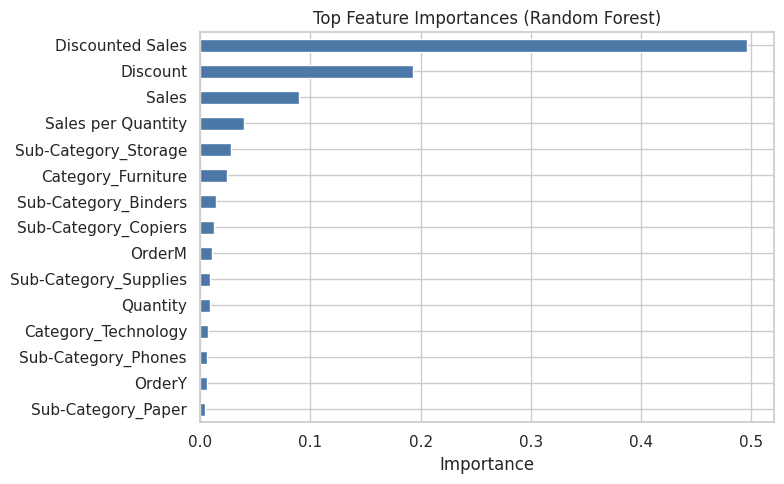

In [52]:
try:
    pre = pipe.named_steps["preprocess"]
    feat_names = pre.get_feature_names_out()
    model = pipe.named_steps["model"]
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
except Exception as e:
    print("RF direct importances unavailable. Falling back to permutation importance.")
    print("Error:", e)
    perm = permutation_importance(
        pipe,
        X_test,
        y_test,
        n_repeats=5,
        n_jobs=1,
        random_state=RANDOM_SEED,
    )
    feat_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

feat_imp.head(50).rename("importance").to_csv(ARTIFACTS_DIR / "feature_importance.csv")

plt.figure(figsize=(8, 5))
feat_imp.head(15).iloc[::-1].plot(kind="barh", color=PRIMARY_COLOR)
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning on GridSearch 

In [53]:
param_grid = {
    "model__n_estimators": [25],
    "model__max_depth": [12, 14],
    "model__min_samples_leaf": [1, 2],
}

grid_cv = TimeSeriesSplit(n_splits=2)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=grid_cv,
    n_jobs=1,
    scoring="r2",
    verbose=1,
)

grid.fit(X_cv, y_cv)

print()
print("[RF Tuned] Best params:", grid.best_params_)
print("[RF Tuned] Best CV R2 :", grid.best_score_)

best_pipe = grid.best_estimator_

Fitting 2 folds for each of 4 candidates, totalling 8 fits



[RF Tuned] Best params: {'model__max_depth': 14, 'model__min_samples_leaf': 1, 'model__n_estimators': 25}
[RF Tuned] Best CV R2 : 0.724892253681826


We tune a compact RandomForest grid using time-aware validation.

The goal is not to over-optimize this small dataset, but to check whether a simple tuned baseline materially improves over the default model.

## XGBoost 

In [54]:
xgb_available = False

try:
    from xgboost import XGBRegressor

    xgb_available = True

    xgb_pipe = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=100,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=1,
        )),
    ])

    cv_scores_xgb = cross_validate(
        xgb_pipe,
        X_cv,
        y_cv,
        cv=TimeSeriesSplit(n_splits=2),
        scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )

    print()
    print("XGBoost Time-Series CV:")
    print(f"R2  : {cv_scores_xgb['test_r2'].mean():.3f} ± {cv_scores_xgb['test_r2'].std():.3f}")
    print(f"RMSE: {-cv_scores_xgb['test_rmse'].mean():.2f} ± {cv_scores_xgb['test_rmse'].std():.2f}")

    xgb_pipe.fit(X_train, y_train)
    y_pred_xgb = xgb_pipe.predict(X_test)

    print("XGB Test RMSE:", rmse_score(y_test, y_pred_xgb))
    print("XGB Test R2  :", r2_score(y_test, y_pred_xgb))

except Exception as e:
    print("XGBoost skipped:", e)
    xgb_available = False


XGBoost Time-Series CV:
R2  : 0.726 ± 0.019
RMSE: 38.31 ± 2.54


XGB Test RMSE: 26.528482276872545
XGB Test R2  : 0.8705543755181658


If XGBoost is available in the environment, we train it as a stronger nonlinear baseline.

The comparison uses the same time-aware split and validation logic as RandomForest.

### Dynamic Model Performance

,CV_R2,CV_R2_std,CV_RMSE,CV_RMSE_std,Test_R2,Test_RMSE
Model,,,,,,
XGBoost,0.726,0.019,38.31,2.54,0.871,26.53
RandomForest (Base),0.712,0.017,39.31,2.42,0.857,27.84
RandomForest (Tuned),0.725,—,—,—,0.806,32.49


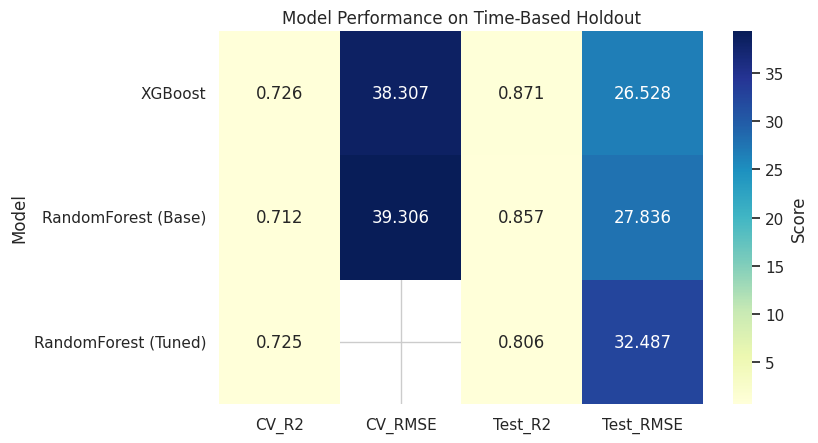

Best holdout model: XGBoost | Test R2=0.871 | Test RMSE=26.53
Saved model artifacts to: artifacts


In [55]:
rf_cv_r2_mean = cv_scores["test_r2"].mean()
rf_cv_r2_std = cv_scores["test_r2"].std()
rf_cv_rmse_mean = -cv_scores["test_rmse"].mean()
rf_cv_rmse_std = cv_scores["test_rmse"].std()

rf_test_r2 = r2_score(y_test, pipe.predict(X_test))
rf_test_rmse = rmse_score(y_test, pipe.predict(X_test))

try:
    rf_tuned_test_pred = best_pipe.predict(X_test)
    rf_tuned_test_r2 = r2_score(y_test, rf_tuned_test_pred)
    rf_tuned_test_rmse = rmse_score(y_test, rf_tuned_test_pred)
    rf_tuned_row = {
        "CV_R2": grid.best_score_,
        "CV_R2_std": np.nan,
        "CV_RMSE": np.nan,
        "CV_RMSE_std": np.nan,
        "Test_R2": rf_tuned_test_r2,
        "Test_RMSE": rf_tuned_test_rmse,
    }
except Exception:
    rf_tuned_row = {
        "CV_R2": np.nan,
        "CV_R2_std": np.nan,
        "CV_RMSE": np.nan,
        "CV_RMSE_std": np.nan,
        "Test_R2": np.nan,
        "Test_RMSE": np.nan,
    }

if xgb_available:
    xgb_cv_r2_mean = cv_scores_xgb["test_r2"].mean()
    xgb_cv_r2_std = cv_scores_xgb["test_r2"].std()
    xgb_cv_rmse_mean = -cv_scores_xgb["test_rmse"].mean()
    xgb_cv_rmse_std = cv_scores_xgb["test_rmse"].std()
    xgb_test_pred = xgb_pipe.predict(X_test)
    xgb_test_r2 = r2_score(y_test, xgb_test_pred)
    xgb_test_rmse = rmse_score(y_test, xgb_test_pred)
else:
    xgb_cv_r2_mean = xgb_cv_r2_std = xgb_cv_rmse_mean = xgb_cv_rmse_std = np.nan
    xgb_test_r2 = xgb_test_rmse = np.nan

perf = pd.DataFrame({
    "Model": ["RandomForest (Base)", "RandomForest (Tuned)", "XGBoost"],
    "CV_R2": [rf_cv_r2_mean, rf_tuned_row["CV_R2"], xgb_cv_r2_mean],
    "CV_R2_std": [rf_cv_r2_std, rf_tuned_row["CV_R2_std"], xgb_cv_r2_std],
    "CV_RMSE": [rf_cv_rmse_mean, rf_tuned_row["CV_RMSE"], xgb_cv_rmse_mean],
    "CV_RMSE_std": [rf_cv_rmse_std, rf_tuned_row["CV_RMSE_std"], xgb_cv_rmse_std],
    "Test_R2": [rf_test_r2, rf_tuned_row["Test_R2"], xgb_test_r2],
    "Test_RMSE": [rf_test_rmse, rf_tuned_row["Test_RMSE"], xgb_test_rmse],
}).set_index("Model")

perf_sorted = perf.sort_values("Test_R2", ascending=False)

best_model_name = perf_sorted["Test_R2"].dropna().idxmax()
best_model_rmse = perf_sorted.loc[best_model_name, "Test_RMSE"]
best_model_r2 = perf_sorted.loc[best_model_name, "Test_R2"]

best_estimators = {
    "RandomForest (Base)": pipe,
    "RandomForest (Tuned)": best_pipe,
}
if xgb_available:
    best_estimators["XGBoost"] = xgb_pipe

best_estimator = best_estimators.get(best_model_name)

display(perf_sorted.style.format({
    "CV_R2": "{:.3f}",
    "CV_R2_std": "{:.3f}",
    "CV_RMSE": "{:.2f}",
    "CV_RMSE_std": "{:.2f}",
    "Test_R2": "{:.3f}",
    "Test_RMSE": "{:.2f}",
}, na_rep="—"))

perf_sorted.to_csv(ARTIFACTS_DIR / "model_performance.csv")
if best_estimator is not None:
    joblib.dump(best_estimator, ARTIFACTS_DIR / "best_profit_model.joblib")

plt.figure(figsize=(8.5, 4.6))
sns.heatmap(
    perf_sorted[["CV_R2", "CV_RMSE", "Test_R2", "Test_RMSE"]],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "Score"},
)
plt.title("Model Performance on Time-Based Holdout")
plt.tight_layout()
plt.show()

print(f"Best holdout model: {best_model_name} | Test R2={best_model_r2:.3f} | Test RMSE={best_model_rmse:.2f}")
print(f"Saved model artifacts to: {ARTIFACTS_DIR}")

## Model Performance

The table above is generated directly from the latest run, so the reported metrics stay synchronized with the notebook outputs.

The comparison uses:

- expanding-window cross-validation on a recent training slice
- a later time-based holdout period for final testing
- RMSE and R² as complementary regression metrics

The best model should be treated as a **baseline candidate** for a margin monitoring dashboard, not as a final production model without monitoring and drift checks.

## XGBoost Feature Importances


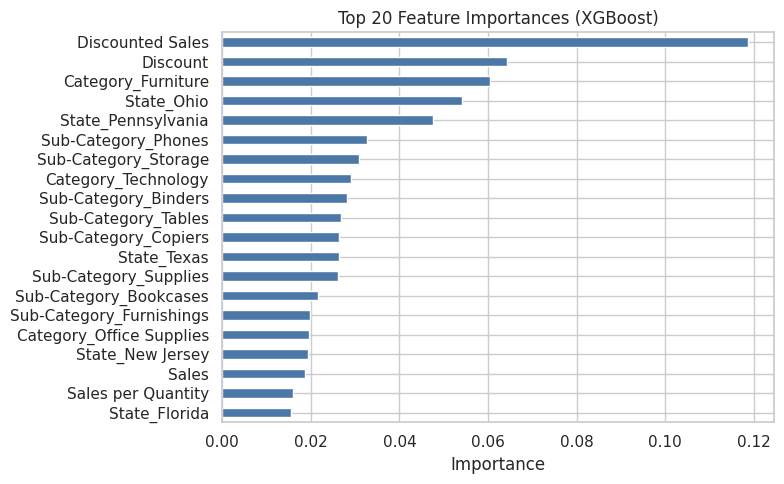

In [56]:
if xgb_available:
    try:
        feat_names = xgb_pipe.named_steps["preprocess"].get_feature_names_out()
        xgb_model = xgb_pipe.named_steps["xgb"]

        imp = (
            pd.Series(xgb_model.feature_importances_, index=feat_names)
            .sort_values(ascending=False)
            .head(20)
        )

        plt.figure(figsize=(8, 5))
        imp.iloc[::-1].plot(kind="barh", color=PRIMARY_COLOR)
        plt.title("Top 20 Feature Importances (XGBoost)")
        plt.xlabel("Importance")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("XGBoost importances not available:", e)

Feature importance helps explain which variables the model relies on most.

For production use, this should be paired with business review to avoid over-trusting discount or sales-derived variables without validating discount policy assumptions.

## Exploratory Monthly Sales Forecast

,MAE,RMSE
Model,,
Seasonal Naive,"20,459.89","23,430.16"
Holt-Winters,"12,932.31","17,770.12"


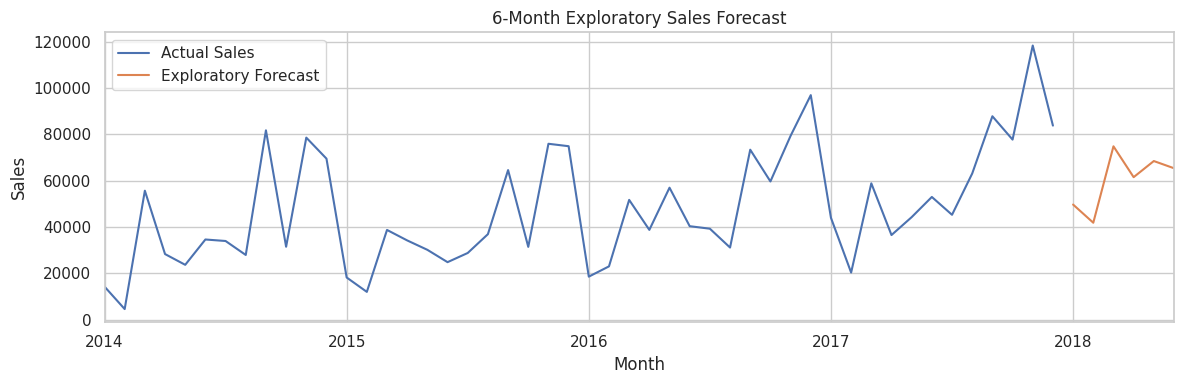

In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y_series = sales_month_by_period.asfreq("M").fillna(0)

forecast_horizon = 6
train_ts = y_series.iloc[:-forecast_horizon]
test_ts = y_series.iloc[-forecast_horizon:]

seasonal_naive_values = train_ts.iloc[-12:-12 + forecast_horizon].values
seasonal_naive_pred = pd.Series(seasonal_naive_values, index=test_ts.index)

hw_model = ExponentialSmoothing(
    train_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hw_fit = hw_model.fit(optimized=True)

hw_test_pred = hw_fit.forecast(forecast_horizon)

forecast_eval = pd.DataFrame({
    "Model": ["Seasonal Naive", "Holt-Winters"],
    "MAE": [
        mean_absolute_error(test_ts, seasonal_naive_pred),
        mean_absolute_error(test_ts, hw_test_pred),
    ],
    "RMSE": [
        rmse_score(test_ts, seasonal_naive_pred),
        rmse_score(test_ts, hw_test_pred),
    ],
}).set_index("Model")

forecast_eval.to_csv(ARTIFACTS_DIR / "forecast_evaluation.csv")

display(forecast_eval.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}"}))

hw_full = ExponentialSmoothing(
    y_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hw_full_fit = hw_full.fit(optimized=True)

future_idx = pd.date_range(
    y_series.index[-1] + pd.offsets.MonthEnd(1),
    periods=forecast_horizon,
    freq="M",
)

fcast = pd.Series(hw_full_fit.forecast(forecast_horizon).values, index=future_idx)

plt.figure(figsize=(12, 4))
y_series.plot(label="Actual Sales")
fcast.plot(label="Exploratory Forecast")
plt.legend()
plt.title("6-Month Exploratory Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

This forecast is intentionally lightweight.

It uses Holt-Winters as an exploratory monthly baseline and compares it against a seasonal naive benchmark on the last six observed months.

Use this section for planning direction, not for production-grade demand forecasting. A production forecast should include richer backtesting, exogenous variables, promotion calendars, uncertainty intervals, and model monitoring.

In [58]:
insights_md = f"""
# Decisions and Takeaways

- Historical sales show clear seasonality, with December often appearing among the strongest sales months.
- **{kpis['highest_region']}** leads by sales, while **{kpis['top_category']}** is the top category by sales.
- Average shipping time is approximately **{kpis['avg_ship_days']:.2f} days**, making it a useful operational KPI to monitor alongside sales and profit.
- RFM segmentation splits customers into actionable groups: Champions, Loyal, Potential, and At Risk.
- Discount-heavy and loss-making sub-categories need review because high revenue volume does not always translate into strong profit quality.
- The best profit prediction baseline in this run is **{best_model_name}**, with **Test R² = {best_model_r2:.3f}** and **Test RMSE = {best_model_rmse:.2f}** on a time-based holdout.
- The monthly sales forecast provides a useful starting point for planning, but a dedicated forecasting workflow with stronger backtesting would be needed before using it for production decisions.

## Next Steps

- Package the profit prediction workflow into a margin monitoring dashboard.
- Monitor prediction drift by month, category, region, and discount band.
- Add scenario analysis for discount changes and loss-making sub-categories.
- Build a dedicated forecasting notebook if future monthly sales prediction becomes the main goal.
"""
display(Markdown(insights_md))


# Decisions and Takeaways

- Historical sales show clear seasonality, with December often appearing among the strongest sales months.
- **West** leads by sales, while **Technology** is the top category by sales.
- Average shipping time is approximately **3.96 days**, making it a useful operational KPI to monitor alongside sales and profit.
- RFM segmentation splits customers into actionable groups: Champions, Loyal, Potential, and At Risk.
- Discount-heavy and loss-making sub-categories need review because high revenue volume does not always translate into strong profit quality.
- The best profit prediction baseline in this run is **XGBoost**, with **Test R² = 0.871** and **Test RMSE = 26.53** on a time-based holdout.
- The monthly sales forecast provides a useful starting point for planning, but a dedicated forecasting workflow with stronger backtesting would be needed before using it for production decisions.

## Next Steps

- Package the profit prediction workflow into a margin monitoring dashboard.
- Monitor prediction drift by month, category, region, and discount band.
- Add scenario analysis for discount changes and loss-making sub-categories.
- Build a dedicated forecasting notebook if future monthly sales prediction becomes the main goal.
